In [1]:
from pathlib import Path
import datetime as dt

import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# Paths and source settings
ROOT_DIR = Path("Fig4") if Path("Fig4").exists() else Path(".")
OBS_DIR = ROOT_DIR / "data/station_wspd_wdir/results_obs_newT"
SIM_DIR = ROOT_DIR / "data/station_wspd_wdir/results_sim_newT"

MODELS = ["pangu", "graphcast", "fengwu", "fuxi", "aurora"]
LEAD = "24h"
SOURCE_ORDER = ["obs", *MODELS]


def read_metric_sources(metric_name: str) -> dict[str, pd.DataFrame]:
    """Load observation + model CSVs for one metric."""
    obs_path = OBS_DIR / f"{metric_name}_obs.csv"
    if not obs_path.exists():
        raise FileNotFoundError(f"Missing input file: {obs_path}")

    data = {"obs": pd.read_csv(obs_path)}
    for model_name in MODELS:
        file_path = SIM_DIR / f"{model_name}_{metric_name}_sim_{LEAD}.csv"
        if not file_path.exists():
            raise FileNotFoundError(f"Missing input file: {file_path}")
        data[model_name] = pd.read_csv(file_path)
    return data


SPEED_DATA_RAW = {
    "mean": read_metric_sources("mean_wspd"),
    "max": read_metric_sources("max_wspd"),
}
WDIR_DATA_RAW = read_metric_sources("mean_wdir")

In [3]:
FONT_BASE = 20
FONT_LABEL = 20
FONT_TICK = 20
FONT_LEGEND = 16

MODEL_STYLES = {
    "pangu": {"label": "Pangu_WRF", "color": "#f58518", "marker": "s"},
    "graphcast": {"label": "GraphCast_WRF", "color": "#54a24b", "marker": "^"},
    "fengwu": {"label": "FengWu_WRF", "color": "#e45756", "marker": "D"},
    "fuxi": {"label": "FuXi_WRF", "color": "#72b7b2", "marker": "v"},
    "aurora": {"label": "Aurora_WRF", "color": "#b279a2", "marker": "p"},
}
OBS_STYLE = {"label": "Observation", "color": "#2f2f2f", "marker": "o"}

STATIONS = ["hko", "cch", "sek", "ngp"]
START_TIME = pd.Timestamp("2025-09-23 10:00", tz="UTC")
END_TIME = pd.Timestamp("2025-09-24 10:00", tz="UTC")
WINDOW_TAG = f"{START_TIME:%Y%m%d-%H}_to_{END_TIME:%Y%m%d-%H}"

OUT_DIR = ROOT_DIR / "publish"
OUT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update(
    {
        "font.family": "Arial",
        "font.sans-serif": ["Arial"],
        "font.size": FONT_BASE,
        "axes.labelsize": FONT_LABEL,
        "xtick.labelsize": FONT_TICK,
        "ytick.labelsize": FONT_TICK,
        "legend.fontsize": FONT_LEGEND,
    }
)


def apply_daychange_hour_ticks(ax: plt.Axes, interval_hours: int = 3) -> None:
    """One-line ticks: HHZ; add MM-DD only when day changes."""
    locator = mdates.HourLocator(interval=interval_hours)
    ax.xaxis.set_major_locator(locator)
    ax.figure.canvas.draw()
    ticks = ax.get_xticks()
    tick_dts = mdates.num2date(ticks, tz=dt.timezone.utc)

    labels: list[str] = []
    prev_date = None
    for d in tick_dts:
        if (prev_date is None) or (d.date() != prev_date):
            labels.append(d.strftime("%m-%d %HZ"))
        else:
            labels.append(d.strftime("%HZ"))
        prev_date = d.date()

    ax.xaxis.set_major_locator(mticker.FixedLocator(ticks))
    ax.set_xticklabels(labels)


def parse_and_subset(
    df: pd.DataFrame,
    stations: list[str],
    start_time: pd.Timestamp,
    end_time: pd.Timestamp,
    ts_col: str = "timestamp_utc",
    ts_format: str = "%Y%m%d %H%M",
) -> pd.DataFrame:
    """Parse timestamps; subset to stations/time window; coerce station values to numeric."""
    missing = [col for col in [ts_col, *stations] if col not in df.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    data = df[[ts_col, *stations]].copy()
    data[ts_col] = pd.to_datetime(data[ts_col], format=ts_format, utc=True, errors="coerce")
    data = data.dropna(subset=[ts_col])

    time_mask = (data[ts_col] >= start_time) & (data[ts_col] <= end_time)
    data = data.loc[time_mask].sort_values(ts_col).reset_index(drop=True)
    data[stations] = data[stations].apply(pd.to_numeric, errors="coerce")
    return data


def prepare_sources(raw_sources: dict[str, pd.DataFrame]) -> dict[str, pd.DataFrame]:
    return {
        source: parse_and_subset(df, STATIONS, START_TIME, END_TIME)
        for source, df in raw_sources.items()
    }


SPEED_DATA = {kind: prepare_sources(raw) for kind, raw in SPEED_DATA_RAW.items()}

print("Prepared speed datasets:", ", ".join(SPEED_DATA.keys()))
print("Prepared sources:", ", ".join(SOURCE_ORDER))
print("Stations:", ", ".join(station.upper() for station in STATIONS))
print("Time window:", START_TIME, "to", END_TIME)
print("Output dir:", OUT_DIR)

Prepared speed datasets: mean, max
Prepared sources: obs, pangu, graphcast, fengwu, fuxi, aurora
Stations: HKO, CCH, SEK, NGP
Time window: 2025-09-23 10:00:00+00:00 to 2025-09-24 10:00:00+00:00
Output dir: publish


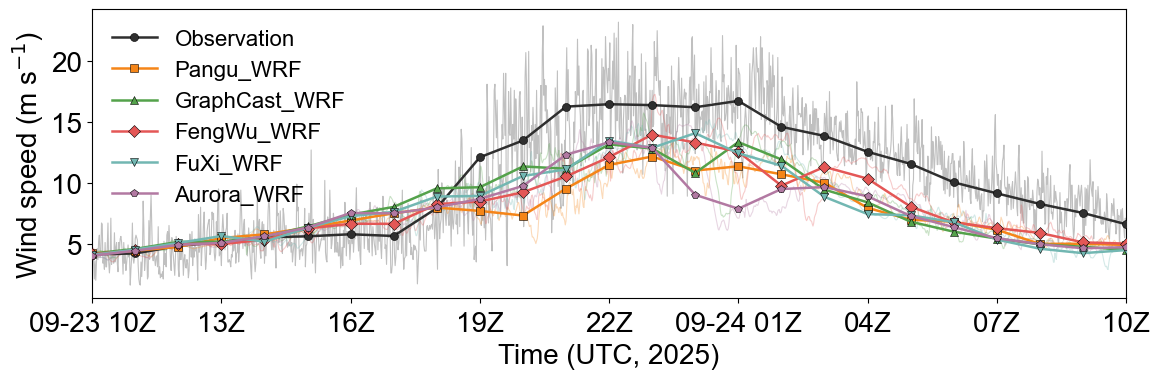

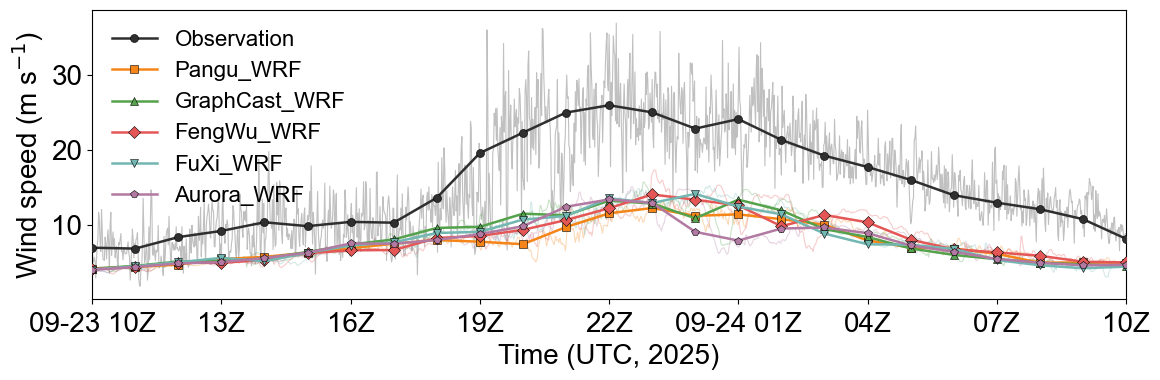

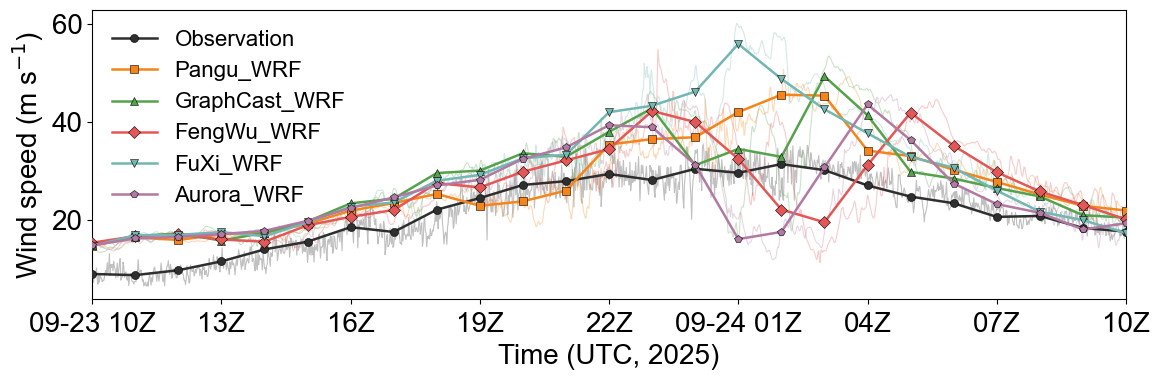

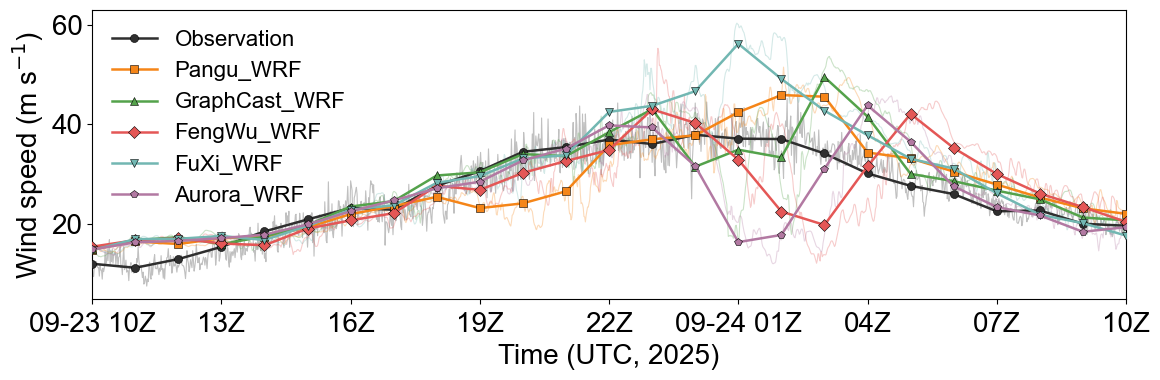

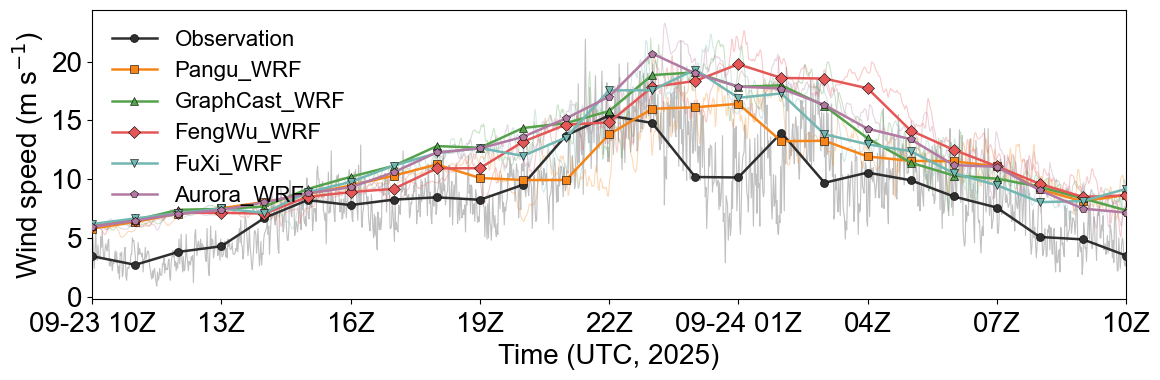

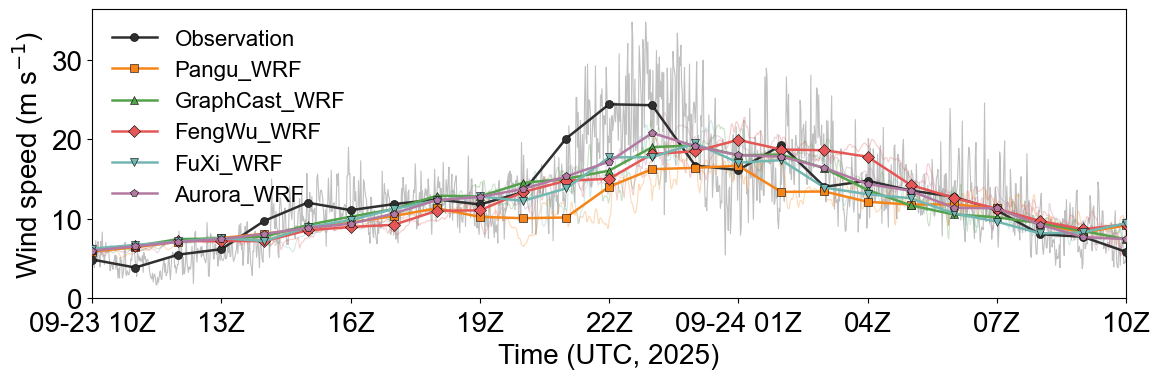

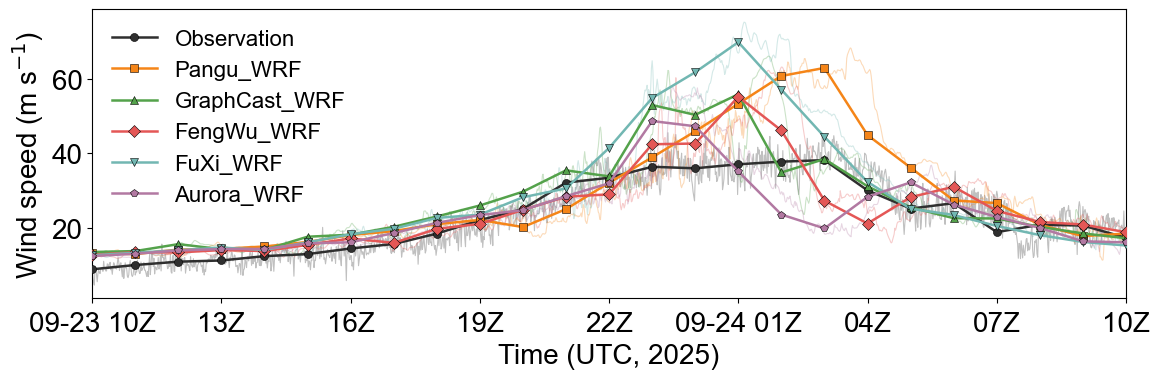

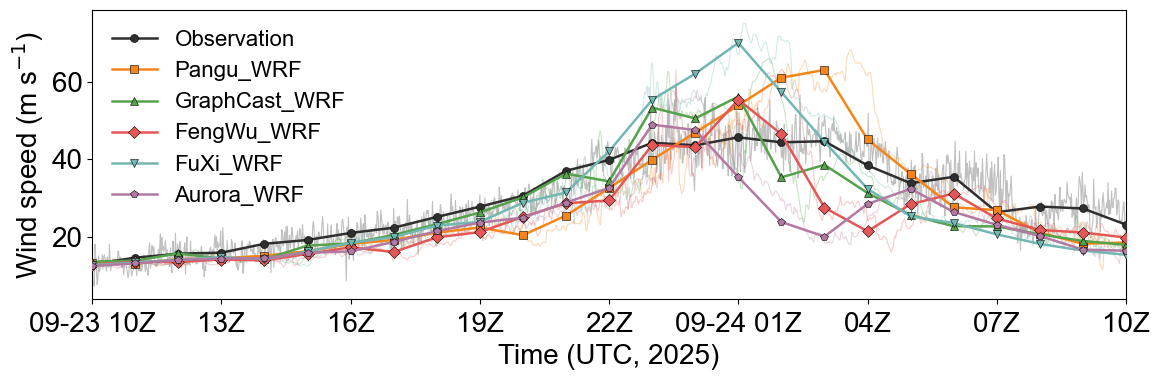

{'mean': [WindowsPath('publish/hko_meanwspd_obs_ai_24h_20250923-10_to_20250924-10.tif'),
  WindowsPath('publish/cch_meanwspd_obs_ai_24h_20250923-10_to_20250924-10.tif'),
  WindowsPath('publish/sek_meanwspd_obs_ai_24h_20250923-10_to_20250924-10.tif'),
  WindowsPath('publish/ngp_meanwspd_obs_ai_24h_20250923-10_to_20250924-10.tif')],
 'max': [WindowsPath('publish/hko_maxwspd_obs_ai_24h_20250923-10_to_20250924-10.tif'),
  WindowsPath('publish/cch_maxwspd_obs_ai_24h_20250923-10_to_20250924-10.tif'),
  WindowsPath('publish/sek_maxwspd_obs_ai_24h_20250923-10_to_20250924-10.tif'),
  WindowsPath('publish/ngp_maxwspd_obs_ai_24h_20250923-10_to_20250924-10.tif')]}

In [4]:
def get_source_style(source_key: str) -> dict:
    return OBS_STYLE if source_key == "obs" else MODEL_STYLES[source_key]


def plot_station_speed(station: str, speed_data: dict[str, pd.DataFrame], file_tag: str):
    fig, ax = plt.subplots(figsize=(12, 4.2))

    for source_key in SOURCE_ORDER:
        style = get_source_style(source_key)
        source_df = speed_data[source_key]

        raw = source_df[["timestamp_utc", station]].dropna()
        ax.plot(
            raw["timestamp_utc"],
            raw[station],
            color=style["color"],
            linewidth=0.8,
            alpha=0.30,
            zorder=1,
        )

        hourly = raw.set_index("timestamp_utc")[station].resample("1h").mean().dropna()
        ax.plot(
            hourly.index,
            hourly.values,
            color=style["color"],
            linewidth=1.8,
            marker=style["marker"],
            markersize=5.8,
            markeredgecolor="black",
            markeredgewidth=0.4,
            linestyle="-",
            label=style["label"],
            zorder=3,
        )

    ax.set_xlabel("Time (UTC, 2025)", fontsize=FONT_LABEL)
    ax.set_ylabel("Wind speed (m s$^{-1}$)", fontsize=FONT_LABEL)
    ax.set_xlim(START_TIME, END_TIME)
    apply_daychange_hour_ticks(ax, interval_hours=3)
    ax.tick_params(axis="x", rotation=0, labelsize=FONT_TICK, pad=6)
    ax.tick_params(axis="y", labelsize=FONT_TICK)
    ax.grid(False)
    ax.legend(loc="upper left", ncol=1, frameon=False, fontsize=FONT_LEGEND)

    fig.tight_layout()
    output_path = OUT_DIR / f"{station}_{file_tag}_obs_ai_{LEAD}_{WINDOW_TAG}.tif"
    fig.savefig(output_path, dpi=600, bbox_inches="tight")
    plt.show()
    return output_path


speed_output_files = {"mean": [], "max": []}
for station_name in STATIONS:
    speed_output_files["mean"].append(
        plot_station_speed(station=station_name, speed_data=SPEED_DATA["mean"], file_tag="meanwspd")
    )
    speed_output_files["max"].append(
        plot_station_speed(station=station_name, speed_data=SPEED_DATA["max"], file_tag="maxwspd")
    )

speed_output_files

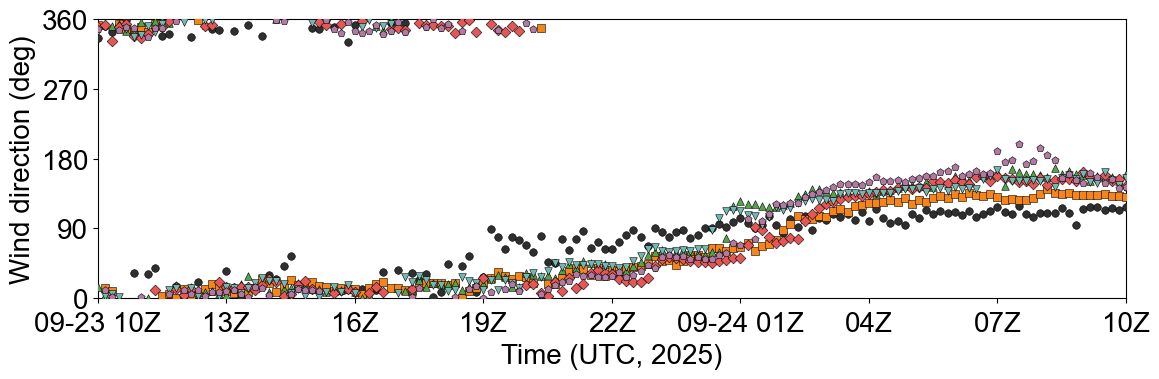

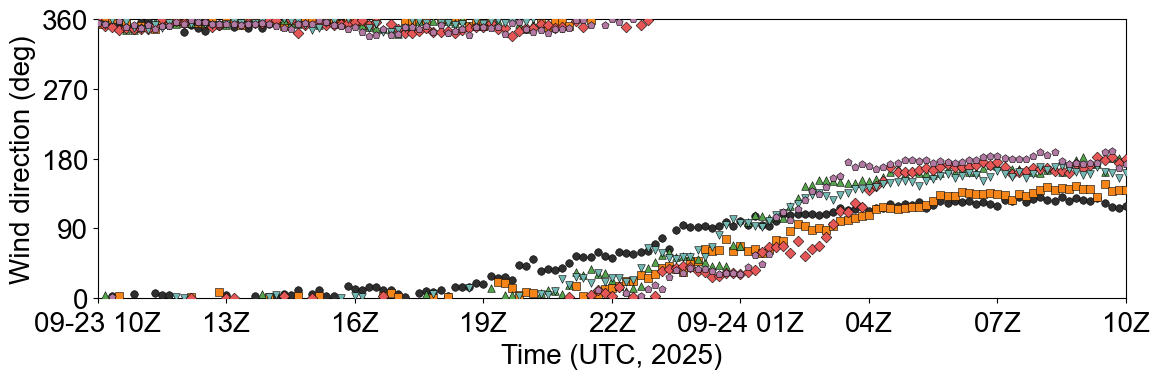

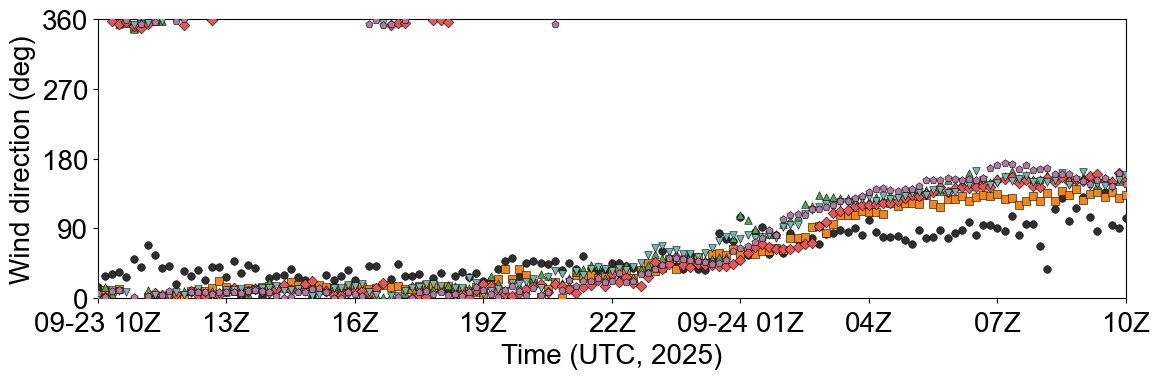

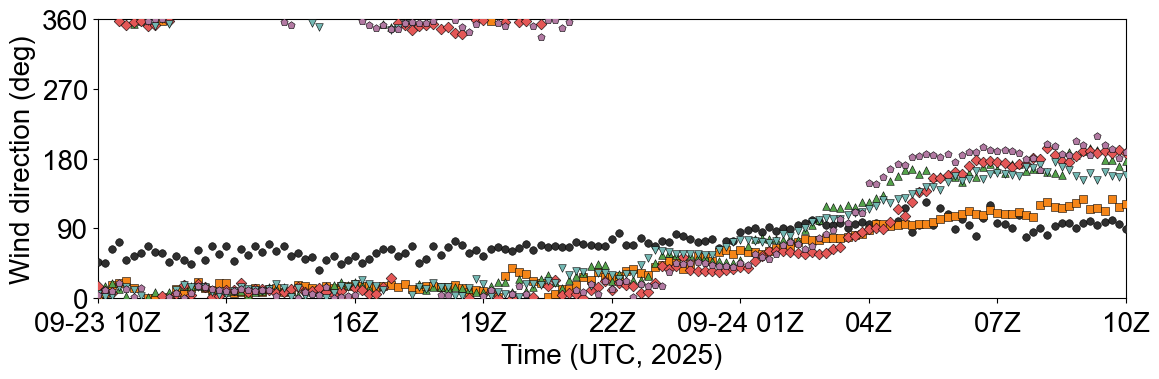

[WindowsPath('publish/hko_wdir_obs_ai_24h_20250923-10_to_20250924-10.tif'),
 WindowsPath('publish/cch_wdir_obs_ai_24h_20250923-10_to_20250924-10.tif'),
 WindowsPath('publish/sek_wdir_obs_ai_24h_20250923-10_to_20250924-10.tif'),
 WindowsPath('publish/ngp_wdir_obs_ai_24h_20250923-10_to_20250924-10.tif')]

In [5]:
# --- Wind direction (10-min downsample, scatter only) ---
WDIR_DATA = prepare_sources(WDIR_DATA_RAW)


def downsample_every_n_points(df: pd.DataFrame, station: str, step: int = 10) -> pd.Series:
    s = df[["timestamp_utc", station]].dropna().set_index("timestamp_utc")[station]
    return s.iloc[::step]


def plot_station_wdir_scatter(station: str, wdir_data: dict[str, pd.DataFrame], file_tag: str = "wdir"):
    fig, ax = plt.subplots(figsize=(12, 4.2))

    for source_key in SOURCE_ORDER:
        style = get_source_style(source_key)
        source_df = wdir_data[source_key]
        down10 = downsample_every_n_points(source_df, station, step=10)

        ax.scatter(
            down10.index,
            down10.values,
            color=style["color"],
            marker=style["marker"],
            s=30,
            edgecolors="black",
            linewidths=0.4,
            label=style["label"],
            zorder=3,
        )

    ax.set_xlabel("Time (UTC, 2025)", fontsize=FONT_LABEL)
    ax.set_ylabel("Wind direction (deg)", fontsize=FONT_LABEL)
    ax.set_xlim(START_TIME, END_TIME)
    apply_daychange_hour_ticks(ax, interval_hours=3)
    ax.tick_params(axis="x", rotation=0, labelsize=FONT_TICK, pad=6)
    ax.tick_params(axis="y", labelsize=FONT_TICK)
    ax.set_ylim(0, 360)
    ax.set_yticks([0, 90, 180, 270, 360])
    ax.grid(False)
    # ax.legend(loc="upper left", ncol=1, frameon=False, fontsize=FONT_LEGEND)

    fig.tight_layout()
    output_path = OUT_DIR / f"{station}_{file_tag}_obs_ai_{LEAD}_{WINDOW_TAG}.tif"
    fig.savefig(output_path, dpi=600, bbox_inches="tight")
    plt.show()
    return output_path


wdir_output_files = [plot_station_wdir_scatter(station_name, WDIR_DATA) for station_name in STATIONS]
wdir_output_files

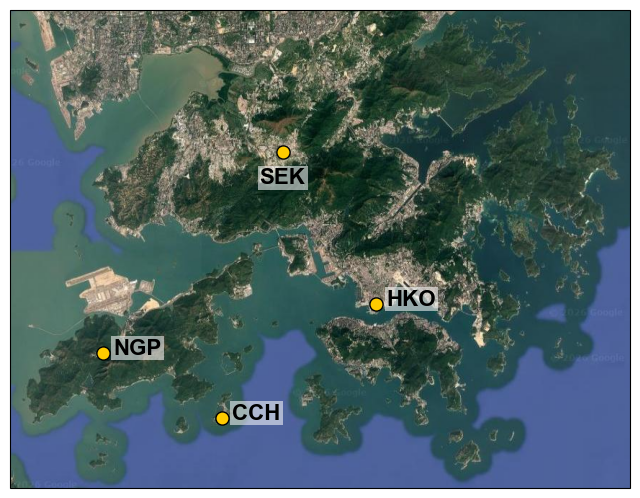

WindowsPath('publish/hk_four_stations_satellite_map.tif')

In [8]:
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt

lat_min, lat_max, lon_min, lon_max = (22.139, 22.562, 113.824, 114.417)

station_file = ROOT_DIR / "data/weather_station_location.xlsx"
station_df = pd.read_excel(station_file, sheet_name="Sheet2")
station_df.columns = station_df.columns.astype(str).str.strip()

station_col, lat_col, lon_col = ("pfx", "纬度", "经度")
plot_stations = STATIONS

station_df[station_col] = station_df[station_col].astype(str).str.strip().str.lower()
selected = station_df.loc[station_df[station_col].isin(plot_stations), [station_col, lat_col, lon_col]].copy()

missing = sorted(set(plot_stations) - set(selected[station_col]))
if missing:
    raise ValueError(f"Missing station coordinates for: {missing}")

selected[[lat_col, lon_col]] = selected[[lat_col, lon_col]].apply(pd.to_numeric, errors="coerce")
selected = selected.dropna(subset=[lat_col, lon_col])

tiler = cimgt.GoogleTiles(style="satellite")
fig = plt.figure(figsize=(8, 8))
ax = plt.axes(projection=tiler.crs)
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
ax.add_image(tiler, 11)

ax.scatter(
    selected[lon_col],
    selected[lat_col],
    s=90,
    c="#ffcc00",
    edgecolors="black",
    linewidths=1.0,
    transform=ccrs.PlateCarree(),
    zorder=6,
)

for _, row in selected.iterrows():
    station_key = str(row[station_col]).strip().lower()

    if station_key == "sek":
        x = row[lon_col]
        y = row[lat_col] - 0.014
        ha = "center"
        va = "top"
    else:
        x = row[lon_col] + 0.010
        y = row[lat_col] + 0.004
        ha = "left"
        va = "center"

    ax.text(
        x,
        y,
        station_key.upper(),
        transform=ccrs.PlateCarree(),
        fontsize=16,
        color="black",
        weight="bold",
        ha=ha,
        va=va,
        zorder=7,
        bbox=dict(facecolor="white", alpha=0.55, edgecolor="none", pad=1.5),
    )

map_output = OUT_DIR / "hk_four_stations_satellite_map.tif"
fig.savefig(map_output, dpi=600, bbox_inches="tight")
plt.show()

map_output